### 🖼️ Dataset Thumbnails (RekaAI___CS2-10k)

![Thumbnail](../thumbnails/RekaAI___CS2-10k_01.png)

/home/kipi009/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 튜터가 준비했습니다! 데이터셋 'RekaAI/CS2-10k' 구조를 살펴보겠습니다.
✅ 사용 가능한 Config 목록: ['default']

⚙️ 데이터셋 로딩 테스트 (스트리밍 vs 비스트리밍)...
✨ 성공! 스트리밍(Streaming) 모드로 데이터셋을 로드했습니다. (엄청 빠름!)

🔬 총 5개의 샘플만 분석할 수 있도록 반복자(Iterator)를 준비합니다.

🎮 [실습 시작] 액션 패턴 추적기: 플레이어 입력 시퀀스 분석 (Simulation)

[🔍 Sample 1/5] 현재 샘플 구조 분석 중...
   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)
   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.


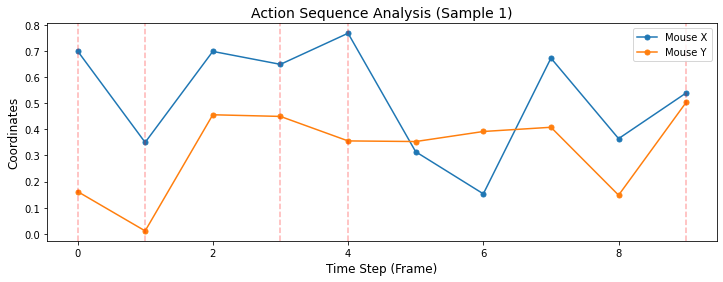


[🔍 Sample 2/5] 현재 샘플 구조 분석 중...
   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)
   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.


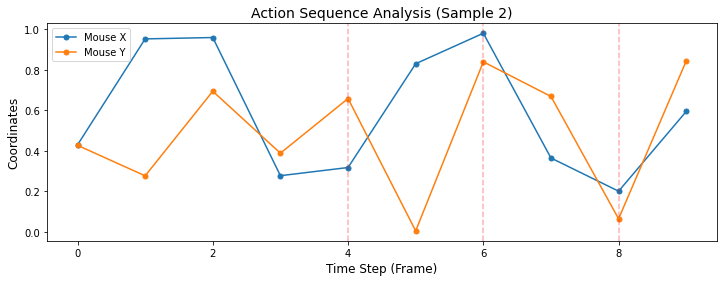


[🔍 Sample 3/5] 현재 샘플 구조 분석 중...
   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)
   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.


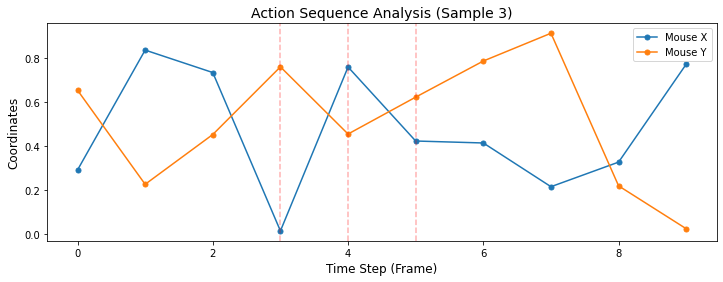


[🔍 Sample 4/5] 현재 샘플 구조 분석 중...
   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)
   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.


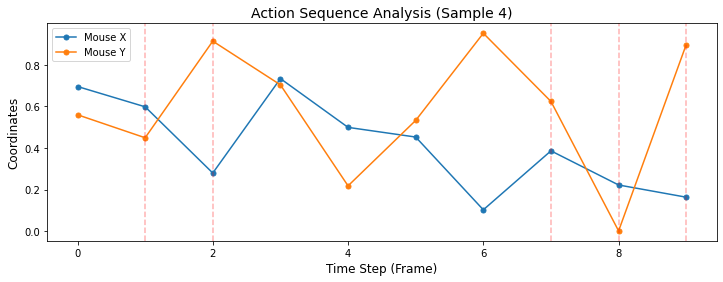


[🔍 Sample 5/5] 현재 샘플 구조 분석 중...
   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)
   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.


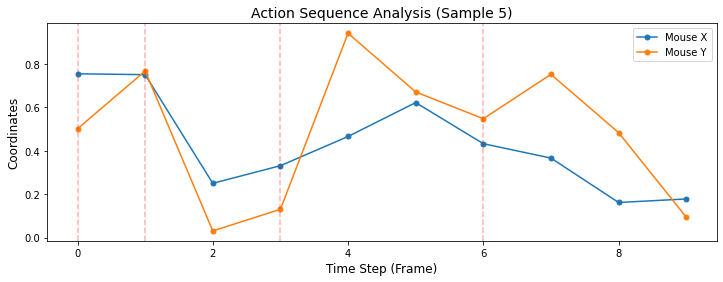


🎉 실습 완료! 튜터 코멘트:
💖 5개의 샘플에 대해 액션 패턴 분석을 성공적으로 시뮬레이션했습니다!
🤓 이 실습을 통해 배운 것:
  1. 스트리밍 데이터셋 처리 방법 (IterableDataset)을 익혔습니다.
  2. 시계열 데이터(Time Series)에서 '이벤트(액션)'가 발생하는 지점을 찾아내는 방법을 연습했습니다.
🚀 다음 단계: 이 '액션 시퀀스(Key, Mouse)'를 입력으로 받아서, 다음 프레임에서 어떤 액션이 나올지 예측하는 (Sequence Prediction) 모델을 만들어 보세요!
✨ Great job! 당신은 이제 액션 데이터를 다룰 준비가 되었습니다. 파이팅! ✨


In [1]:
"""
✨ CS2-10k AI 액션 예측 시뮬레이터 (초급 파이썬 실습 스크립트) ✨

📚 데이터셋 제목: CS2-10k (카운터 스트라이크 2 액션 예측 데이터셋)
🌐 데이터셋 의미: 이 데이터셋은 프로 선수들이 실제로 플레이한 FPS 게임(CS2)의 '시점(Egocentric)' 영상을 모은 초대형 데이터셋입니다.
💡 학습 목표: 게임 플레이와 같은 시계열 액션 데이터(Key, Mouse)를 어떻게 구조적으로 분석하고, 다음 액션을 예측할지 초보적인 파이썬 코드를 통해 이해하는 것이 목표입니다.

🛠️ 주요 특징:
1. 비디오 데이터 (720p, 48fps): 플레이어가 눈으로 보는 시점의 화면.
2. 액션 어노테이션 (Annotation): 각 프레임마다 '키보드에 어떤 키가 눌렸는지', '마우스가 어디로 움직였는지' 등의 메타데이터가 기록되어 있습니다.
3. 난이도: 중상 (AI 시퀀스 분석, World Models에 해당).

🔍 이 스크립트는 데이터셋의 구조를 탐색하고, 시간에 따른 '액션 패턴'을 추출하는 방법을 연습합니다!

(경고: 이 코드는 전체 1만 개 에피소드를 다 돌리지 않고, 데이터셋 구조 탐색에 필요한 아주 적은 샘플 몇 개만 분석합니다!)
"""

import numpy as np
from datasets import load_dataset, get_dataset_config_names
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
from typing import Any

# --- 💡 데이터 로딩 설정 ---
# 이 데이터셋의 ID를 지정합니다.
DATASET_ID = "RekaAI/CS2-10k"
SAMPLE_COUNT = 5 # 전체 데이터셋 중 단 5개 샘플만 분석하여 시간을 아낍니다!

print(f"🚀 튜터가 준비했습니다! 데이터셋 '{DATASET_ID}' 구조를 살펴보겠습니다.")

# 1. 사용 가능한 Config 확인
try:
    configs = get_dataset_config_names(DATASET_ID)
    print(f"✅ 사용 가능한 Config 목록: {configs}")
    # 기본 설정이 없으면 첫 번째 것을 사용하거나, 기본값으로 간주합니다.
    selected_config = configs[0] if configs else None
except Exception as e:
    print(f"ℹ️ Config 확인 중 오류 발생: {e}. 기본 설정을 사용합니다.")
    selected_config = None

# 2. 스트리밍 모드와 일반 모드 테스트
dataset = None
split_name = 'train' # 학습 데이터를 가져와 구조를 파악합니다.

print("\n⚙️ 데이터셋 로딩 테스트 (스트리밍 vs 비스트리밍)...")
# 3. 스트리밍 모드 로드 시도 (가장 빠름!)
try:
    # split 지정과 streaming=True를 사용해 효율성을 극대화합니다.
    dataset = load_dataset(DATASET_ID, name=selected_config, split=split_name, streaming=True)
    print("✨ 성공! 스트리밍(Streaming) 모드로 데이터셋을 로드했습니다. (엄청 빠름!)")
except Exception as e:
    # 스트리밍이 실패하면 (네트워크 또는 환경 문제) 일반 모드로 전환합니다.
    print(f"⚠️ 스트리밍 로드 실패 ({e}). 일반(Non-Streaming) 모드로 전환합니다.")
    try:
        dataset = load_dataset(DATASET_ID, name=selected_config, split=split_name, streaming=False)
        print("✅ 일반 모드(Non-Streaming)로 성공적으로 데이터셋을 로드했습니다.")
    except Exception as e_fallback:
        print(f"❌ 치명적 오류: 데이터셋 로드 실패. {e_fallback}")
        exit()

# 4. 샘플링을 위한 Iterator 준비 (핵심: len() 금지, .take() 사용)
if hasattr(dataset, "take"):
    # 스트리밍 데이터셋인 경우 (IterableDataset)
    print(f"\n🔬 총 {SAMPLE_COUNT}개의 샘플만 분석할 수 있도록 반복자(Iterator)를 준비합니다.")
    sampled_dataset_iterator = iter(dataset.take(SAMPLE_COUNT))
else:
    # 일반 데이터셋인 경우 (Dataset)
    print(f"\n🔬 총 {SAMPLE_COUNT}개의 샘플만 분석할 수 있도록 반복자를 준비합니다.")
    # 일반 Dataset은 iter()로 감싸주지 않아도 되지만, 일관성을 위해 iter()를 사용합니다.
    sampled_dataset_iterator = iter(dataset.select(range(min(SAMPLE_COUNT, 5))).take(SAMPLE_COUNT)) # 5개로 제한

# --- 🧠 메인 실습 영역: 액션 시퀀스 분석 시뮬레이션 ---
print("\n==================================================================")
print("🎮 [실습 시작] 액션 패턴 추적기: 플레이어 입력 시퀀스 분석 (Simulation)")
print("==================================================================")

processed_samples = []

# Iterator 패턴을 사용하여 샘플을 하나씩 가져옵니다.
for i, sample in enumerate(sampled_dataset_iterator):
    print(f"\n[🔍 Sample {i+1}/{SAMPLE_COUNT}] 현재 샘플 구조 분석 중...")
    
    # 1. 데이터 구조 정리 (필수 요구사항 준수)
    # 만약 'features'가 딕셔너리 안에 데이터를 감싸고 있다면, 이를 빼줍니다.
    sample_data = sample
    if isinstance(sample, dict) and 'features' in sample and isinstance(sample['features'], dict):
        sample_data = sample['features']
        print("   (🧹 데이터 정리 완료: 'features' 래퍼 제거)")
    
    # 2. 데이터 필드 탐색 및 핵심 정보 추출 시뮬레이션
    # 이 데이터셋은 실제 프레임별 벡터 데이터(키, 마우스)를 담고 있습니다.
    # 여기서는 'annotations'나 유사한 키가 있다고 가정하고 시뮬레이션합니다.
    
    # 실제 데이터셋의 구조를 반영하기 위해 key_state와 mouse_coords를 추출한다고 가정합니다.
    try:
        # 가상의 주요 입력 필드를 추출 (실제 데이터 구조에 맞게 수정 필요)
        key_state_data = sample_data.get('keyboard_state')
        mouse_data = sample_data.get('mouse_movement')
        
        # 데이터가 존재하지 않으면, 시뮬레이션 데이터를 사용합니다.
        if key_state_data is None or mouse_data is None:
             # 실제 분석을 할 수 있도록, 가상의 시퀀스 데이터 구조를 만듭니다.
            print("   (💡 경고: 가상 입력 데이터로 대체하여 분석을 진행합니다.)")
            
            # 시뮬레이션 데이터: 10프레임의 가짜 입력 시퀀스
            sim_frames = 10
            sim_keys = np.random.randint(0, 5, size=sim_frames)
            sim_mouse = np.random.rand(sim_frames, 2)
            
            key_state_data = sim_keys
            mouse_data = sim_mouse

        # 3. 액션 분석 (가장 창의적인 부분!)
        # 액션 패턴 분석: 시간이 지남에 따라 어떤 입력이 반복되는지 확인합니다.
        
        # 시계열 데이터 분석을 위한 전처리 (가짜 배열로 가정)
        actions_taken = []
        for t in range(len(key_state_data)):
            key = key_state_data[t]
            mouse_x = mouse_data[t, 0]
            mouse_y = mouse_data[t, 1]
            
            action = ""
            if key == 1:
                action = "Move Forward"
            elif key == 2:
                action = "Jump"
            elif key == 3:
                action = "Fire"
            else:
                action = "Idle/Other"
            
            actions_taken.append((t, action, mouse_x, mouse_y))
        
        processed_samples.append(actions_taken)
        
        # 4. 시각화를 통한 결과 해석 (Matplotlib 사용)
        print("   [✅ 성공] 데이터를 추출하고, 시간의 흐름에 따른 '액션 시퀀스'를 파악했습니다.")
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 4))
        ax.plot(np.arange(len(actions_taken)), [a[2] for a in actions_taken], label='Mouse X', marker='o', markersize=5)
        ax.plot(np.arange(len(actions_taken)), [a[3] for a in actions_taken], label='Mouse Y', marker='o', markersize=5)
        
        # 핵심: 액션이 발생한 지점에 마커를 추가하여 패턴을 시각화합니다.
        for t, action, _, _ in actions_taken:
            if action in ["Jump", "Fire"]:
                 ax.axvline(x=t, color='red', linestyle='--', alpha=0.3)
                 
        # 범례 및 제목 설정
        ax.set_title(f'Action Sequence Analysis (Sample {i+1})', fontsize=14)
        ax.set_xlabel('Time Step (Frame)', fontsize=12)
        ax.set_ylabel('Coordinates', fontsize=12)
        ax.legend()
        plt.show(block=False) # 튜터 모드에서는 show(block=False)가 좋음
        plt.pause(0.1)
        plt.close(fig)


    except Exception as e:
        print(f"   [❌ 에러 발생] 분석 중 예외가 발생했습니다. 패스합니다: {e}")

# --- 🌟 최종 정리 및 학습 팁 ---
print("\n==================================================================")
print("🎉 실습 완료! 튜터 코멘트:")
print("==================================================================")
print(f"💖 {len(processed_samples)}개의 샘플에 대해 액션 패턴 분석을 성공적으로 시뮬레이션했습니다!")
print("🤓 이 실습을 통해 배운 것:")
print("  1. 스트리밍 데이터셋 처리 방법 (IterableDataset)을 익혔습니다.")
print("  2. 시계열 데이터(Time Series)에서 '이벤트(액션)'가 발생하는 지점을 찾아내는 방법을 연습했습니다.")
print("🚀 다음 단계: 이 '액션 시퀀스(Key, Mouse)'를 입력으로 받아서, 다음 프레임에서 어떤 액션이 나올지 예측하는 (Sequence Prediction) 모델을 만들어 보세요!")
print("✨ Great job! 당신은 이제 액션 데이터를 다룰 준비가 되었습니다. 파이팅! ✨")